# TC-PCA Projection vs PLSSVD Regression Embedding

Two ways to obtain a low-dimensional ring embedding from CA1 population firing rates:

1. **TC-PCA projection** — fit PCA on the tuning-curve matrix (angular bins × neurons), then project time-resolved firing rates onto those PCs. The tuning-curve PCs capture the dominant angular-position structure in the population.
2. **PLSSVD regression** — fit Partial Least-Squares SVD with X = firing rates and `Y = [sin φ, cos φ, sin 2φ, cos 2φ]` as the target, finding directions in firing-rate space that maximally covary with angular position.

**Hypothesis**: both embeddings recover essentially the same ring manifold, because the dominant structure in CA1 population activity *is* the angular-position signal.

We compare them via:
- **Visual inspection** of φ-binned ring trajectories (side-by-side 3-D plots)
- **RSA** (Spearman correlation of pairwise distance matrices)
- **CCA** (first canonical correlation between the two embeddings)
- **R²** (linear regression from one embedding to the other)

In [1]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSSVD
from sklearn.linear_model import LinearRegression
import seaborn as sns

from remapping.dataset import (
    MiceDataset, Animals, GROUP_ORDER,
    EXPERIMENT_ORDER, SESSION_TYPE_MAP,
    EXPERIMENT_TYPE_ORDER, EXPERIMENT_TYPE_COLORS,
)
from remapping.processing import smooth_tuning_curves_circularly, average_by_phi_bin
from remapping.plotting import BehaviorColors, PlotStyle, get_figures_path
from remapping.metrics import rsa_spearman, r_squared
from remapping.alignments import canoncorr

mice = MiceDataset()
colors = BehaviorColors()
style = PlotStyle()
palette = mice.get_group_palette()

In [2]:
# --- Parameters ---

# Processing pipeline
ONLY_MOVING = True
BINS_COMPRESS = 3
BINS_SMOOTHING = 3
BINS_PHI = 360
TC_KERNEL = 20           # circular smoothing kernel for tuning curves

# Embedding dimensions
N_COMPONENTS = 3         # number of PCs / PLS components to compare
MIN_NEURONS = 30         # skip recordings with fewer neurons

# Ring visualisation
N_PHIBINS = 60           # angular bins for ring averaging

# Angular-position colourmap
PHI_CMAP = colors.angular_position

# Figure output
fig_path = get_figures_path("1.embeddings", "02_tc_pca_vs_plssvd")

## 1 — Load all recordings and compute both embeddings

For every subject / FOV / session / run:
- Fit **PCA** on the smoothed tuning curves (360 × N) → project firing rates onto the first `N_COMPONENTS` PCs (**TC-PCA projection**)
- Fit **PLSSVD** with X = firing rates, Y = [sin φ, cos φ, sin 2φ, cos 2φ] → take the first `N_COMPONENTS` X-scores (**PLSSVD embedding**)

In [3]:
records = []

for subject in Animals:
    info = mice.get_subject_info(subject)
    group = f"{info['genotype']}_{info['age']}"
    for fov in mice.get_available_fovs(subject):
        for session in mice.get_available_sessions(subject, fov):
            for run in mice.get_available_runs(subject, fov, session):
                # Load processed firing rates + tuning curves
                firing_rates, phi, time, (cell_ids, _), tc_raw, phi_bins = (
                    mice.load_firing_rates(
                        subject, fov, session, run,
                        only_moving=ONLY_MOVING,
                        bins_compress=BINS_COMPRESS,
                        bins_smoothing=BINS_SMOOTHING,
                        bins_phi=BINS_PHI,
                    )
                )
                n_neurons = firing_rates.shape[1]
                if n_neurons < MIN_NEURONS:
                    continue

                # Drop time-bins where phi is NaN (can occur after temporal binning)
                valid = ~np.isnan(phi)
                if valid.sum() < 100:
                    continue
                firing_rates = firing_rates[valid]
                phi = phi[valid]

                tc = smooth_tuning_curves_circularly(tc_raw, kernel_size=TC_KERNEL)

                # --- TC-PCA projection ---
                pca = PCA(n_components=N_COMPONENTS)
                pca.fit(tc)                          # fit on (360, N) tuning curves
                fr_pca = firing_rates @ pca.components_.T  # project firing rates (T, N) → (T, K)

                # --- PLSSVD regression embedding ---
                phi_rad = np.deg2rad(phi)
                Y_target = np.column_stack([
                    np.sin(phi_rad), np.cos(phi_rad),
                    np.sin(2 * phi_rad), np.cos(2 * phi_rad),
                ])
                pls = PLSSVD(n_components=N_COMPONENTS)
                fr_pls, _ = pls.fit_transform(firing_rates, Y_target)

                # --- φ-binned rings ---
                ring_pca, ring_phi = average_by_phi_bin(fr_pca, phi, N_PHIBINS)
                ring_pls, _       = average_by_phi_bin(fr_pls, phi, N_PHIBINS)

                records.append({
                    "subject": subject, "fov": fov,
                    "session": session, "run": run,
                    "group": group, "n_neurons": n_neurons,
                    "fr_pca": fr_pca, "fr_pls": fr_pls,
                    "ring_pca": ring_pca, "ring_pls": ring_pls,
                    "ring_phi": ring_phi,
                    "phi": phi,
                })

print(f"Computed both embeddings for {len(records)} recordings "
      f"(skipped those with < {MIN_NEURONS} neurons)")

Computed both embeddings for 321 recordings (skipped those with < 30 neurons)


## 2 — Visual comparison: φ-binned ring trajectories

One example per genotype × age group showing the PCA ring alongside the PLSSVD ring, colour-coded by angular position.

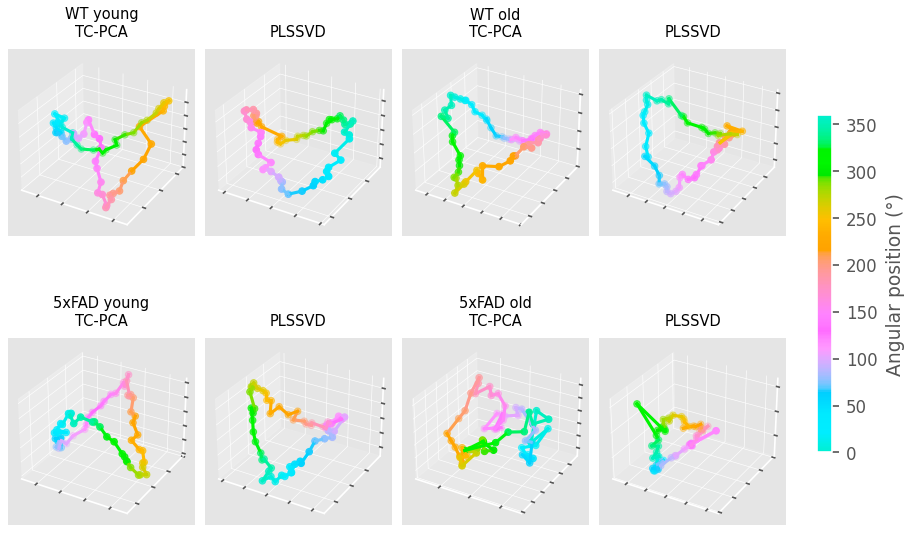

In [4]:
# Pick one representative recording per group (first encountered)
examples = {}
for rec in records:
    if rec["group"] not in examples:
        examples[rec["group"]] = rec

norm = plt.Normalize(0, 360)

fig, axes = plt.subplots(
    2, 4, figsize=(PlotStyle.FULL_WIDTH, 4.5),
    subplot_kw={"projection": "3d"},
)
fig.subplots_adjust(wspace=0.05, hspace=0.25)

for idx, group in enumerate(GROUP_ORDER):
    rec = examples[group]
    row, col_base = divmod(idx, 2)

    for j, (ring, label) in enumerate([
        (rec["ring_pca"], "TC-PCA"),
        (rec["ring_pls"], "PLSSVD"),
    ]):
        ax = axes[row, col_base * 2 + j]
        phi_c = rec["ring_phi"]

        for k in range(len(ring)):
            k1 = (k + 1) % len(ring)
            ax.plot(
                [ring[k, 0], ring[k1, 0]],
                [ring[k, 1], ring[k1, 1]],
                [ring[k, 2], ring[k1, 2]],
                color=PHI_CMAP(norm(phi_c[k])), linewidth=1.5,
            )
        ax.scatter(ring[:, 0], ring[:, 1], ring[:, 2],
                   c=phi_c, cmap=PHI_CMAP, norm=norm, s=10, zorder=5)

        title = f"{group.replace('_', ' ')}\n{label}" if j == 0 else label
        ax.set_title(title, fontsize=7)
        ax.tick_params(labelsize=5)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])

# Colourbar
sm = plt.cm.ScalarMappable(cmap=PHI_CMAP, norm=norm)
cbar_ax = fig.add_axes([0.93, 0.25, 0.015, 0.5])
fig.colorbar(sm, cax=cbar_ax, label="Angular position (°)")

fig.savefig(fig_path / "ring_comparison_examples.pdf")
plt.show()

## 3 — Quantitative similarity: RSA, CCA, R²

For each recording, compute three metrics comparing the PCA and PLSSVD embeddings:

| Metric | What it captures |
|--------|------------------|
| **RSA** (Spearman ρ of pairwise-distance matrices) | Global geometry match — do both embeddings preserve the same distance structure? |
| **CCA dim 1** (first canonical correlation) | Best linear correspondence between the two subspaces |
| **R²** (linear regression from PLSSVD → PCA) | How much variance in PCA is explained by a linear map from PLSSVD? |

In [5]:
metric_records = []

for rec in records:
    fr_pca = rec["fr_pca"]   # (T, K)
    fr_pls = rec["fr_pls"]   # (T, K)

    # RSA — Spearman ρ of pairwise distance matrices on the phi-binned rings
    rsa = rsa_spearman(rec["ring_pca"], rec["ring_pls"])

    # CCA — first canonical correlation on time-resolved embeddings
    cca_r = canoncorr(fr_pca, fr_pls)
    cca_dim1 = cca_r[0]

    # R² — multivariate linear regression PLSSVD → TC-PCA
    reg = LinearRegression().fit(fr_pls, fr_pca)
    pred = reg.predict(fr_pls)
    r2 = r_squared(fr_pca, pred)

    metric_records.append({
        "subject": rec["subject"].value,
        "fov": rec["fov"],
        "session": rec["session"],
        "run": rec["run"],
        "group": rec["group"],
        "n_neurons": rec["n_neurons"],
        "RSA": rsa,
        "CCA_dim1": cca_dim1,
        "R2": r2,
    })

df = pd.DataFrame(metric_records)
metric_names = ["RSA", "CCA_dim1", "R2"]
print(f"Metrics computed for {len(df)} recordings")
df[metric_names].describe().round(3)

Metrics computed for 321 recordings


,RSA,CCA_dim1,R2
count,321.000,321.000,321.000
mean,0.941,0.968,0.855
std,0.059,0.023,0.095
min,0.646,0.863,0.466
25%,0.925,0.959,0.812
50%,0.963,0.974,0.885
75%,0.981,0.984,0.925
max,0.996,0.996,0.976


## 3b — Chance level via circular time-shift null

To establish a chance baseline, we **circularly shift φ in time** before fitting PLSSVD, while keeping the TC-PCA embedding unchanged.

This preserves the autocorrelation structure of both the firing rates and the angular-position signal, but **destroys their temporal coupling**. If the observed similarity is driven by the shared angular-position signal, the null metrics should drop substantially.

For efficiency, we compute the null on a random subset of recordings (one per subject).

In [6]:
N_SHUFFLES = 100
rng = np.random.default_rng(42)

# Use one recording per subject for the null (faster)
null_subset = {}
for rec in records:
    s = rec["subject"].value
    if s not in null_subset:
        null_subset[s] = rec
null_subset = list(null_subset.values())
print(f"Computing null on {len(null_subset)} recordings × {N_SHUFFLES} shuffles ...")

# Reload firing rates for the null subset (we need the full N-dimensional data)
null_data = []
for rec in null_subset:
    firing_rates, phi, _, (_, _), tc_raw, _ = mice.load_firing_rates(
        rec["subject"], rec["fov"], rec["session"], rec["run"],
        only_moving=ONLY_MOVING, bins_compress=BINS_COMPRESS,
        bins_smoothing=BINS_SMOOTHING, bins_phi=BINS_PHI,
    )
    valid = ~np.isnan(phi)
    null_data.append({
        "firing_rates": firing_rates[valid],
        "phi": phi[valid],
        "fr_pca": rec["fr_pca"],
        "ring_pca": rec["ring_pca"],
    })

null_metrics = {m: [] for m in metric_names}

for nd in null_data:
    fr = nd["firing_rates"]
    phi_orig = nd["phi"]
    fr_pca = nd["fr_pca"]
    T = len(phi_orig)

    for _ in range(N_SHUFFLES):
        # Circular shift φ by a random offset (10–90 % of T)
        shift = rng.integers(int(0.1 * T), int(0.9 * T))
        phi_shuf = np.roll(phi_orig, shift)

        # Refit PLSSVD with shifted φ
        phi_rad_shuf = np.deg2rad(phi_shuf)
        Y_shuf = np.column_stack([
            np.sin(phi_rad_shuf), np.cos(phi_rad_shuf),
            np.sin(2 * phi_rad_shuf), np.cos(2 * phi_rad_shuf),
        ])
        pls_shuf = PLSSVD(n_components=N_COMPONENTS)
        fr_pls_shuf, _ = pls_shuf.fit_transform(fr, Y_shuf)

        # Compute metrics against the (unchanged) TC-PCA embedding
        ring_pls_shuf, _ = average_by_phi_bin(fr_pls_shuf, phi_orig, N_PHIBINS)
        null_metrics["RSA"].append(rsa_spearman(nd["ring_pca"], ring_pls_shuf))

        cca_shuf = canoncorr(fr_pca, fr_pls_shuf)
        null_metrics["CCA_dim1"].append(cca_shuf[0])

        reg_shuf = LinearRegression().fit(fr_pls_shuf, fr_pca)
        null_metrics["R2"].append(r_squared(fr_pca, reg_shuf.predict(fr_pls_shuf)))

print("Done.")
for m in metric_names:
    arr = np.array(null_metrics[m])
    print(f"  Null {m}: mean={arr.mean():.3f}, 95th={np.percentile(arr, 95):.3f}")

Computing null on 23 recordings × 100 shuffles ...
Done.
  Null RSA: mean=0.678, 95th=0.932
  Null CCA_dim1: mean=0.680, 95th=0.918
  Null R2: mean=0.374, 95th=0.665


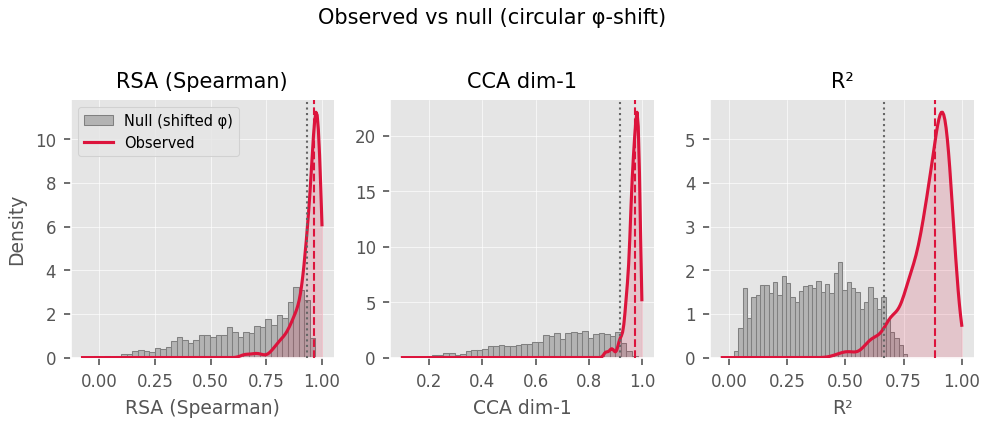

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(PlotStyle.FULL_WIDTH, 2.8))

labels = {"RSA": "RSA (Spearman)", "CCA_dim1": "CCA dim-1", "R2": "R²"}

for ax, m in zip(axes, metric_names):
    null_arr = np.array(null_metrics[m])
    obs_arr = df[m].values

    # Null histogram
    ax.hist(null_arr, bins=40, density=True, color="0.7", edgecolor="0.5",
            linewidth=0.5, label="Null (shifted φ)", zorder=1)

    # Observed distribution (KDE)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(obs_arr)
    x_grid = np.linspace(
        min(null_arr.min(), obs_arr.min()) - 0.05,
        min(max(null_arr.max(), obs_arr.max()) + 0.05, 1.0),
        200,
    )
    ax.plot(x_grid, kde(x_grid), color="crimson", lw=1.5, label="Observed", zorder=3)
    ax.fill_between(x_grid, kde(x_grid), color="crimson", alpha=0.15, zorder=2)

    # Observed median line
    obs_med = np.median(obs_arr)
    ax.axvline(obs_med, color="crimson", ls="--", lw=1, zorder=4)

    # 95th percentile of null
    p95 = np.percentile(null_arr, 95)
    ax.axvline(p95, color="0.4", ls=":", lw=1, zorder=4)

    ax.set_xlabel(labels[m])
    ax.set_ylabel("Density" if m == metric_names[0] else "")
    ax.set_title(labels[m])

axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Observed vs null (circular φ-shift)", fontsize=10, y=1.02)
plt.tight_layout()
fig.savefig(fig_path / "null_distribution.pdf")
plt.show()

## 4 — Metric distributions by genotype × age group

Violin + strip plots for each metric, split by group.

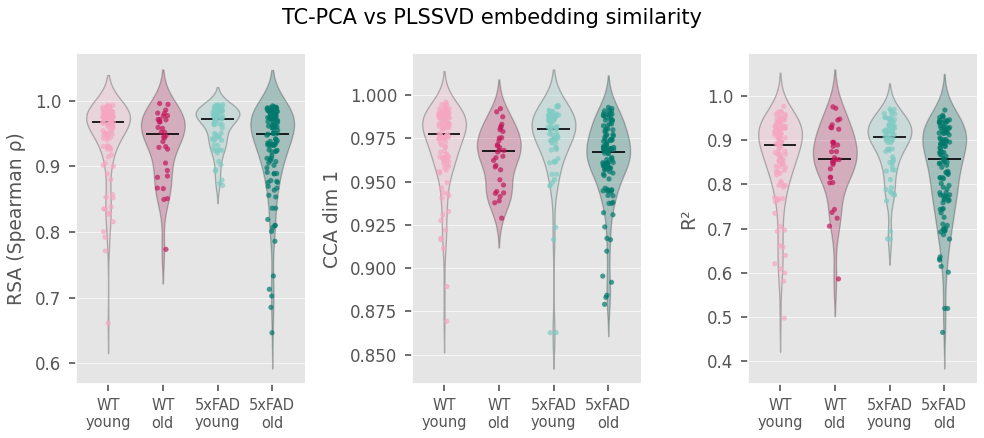

In [8]:
metric_names = ["RSA", "CCA_dim1", "R2"]
metric_labels = ["RSA (Spearman ρ)", "CCA dim 1", "R²"]

fig, axes = plt.subplots(1, 3, figsize=(PlotStyle.FULL_WIDTH, 3.0))

for ax, col, ylabel in zip(axes, metric_names, metric_labels):
    sns.violinplot(
        data=df, x="group", y=col, hue="group",
        order=GROUP_ORDER, hue_order=GROUP_ORDER,
        palette=palette, inner=None, alpha=0.3, ax=ax, legend=False,
    )
    sns.stripplot(
        data=df, x="group", y=col, hue="group",
        order=GROUP_ORDER, hue_order=GROUP_ORDER,
        palette=palette, size=2.5, alpha=0.7, jitter=True, ax=ax, legend=False,
    )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels([g.replace("_", "\n") for g in GROUP_ORDER], fontsize=7)

    # Add median line
    for i, g in enumerate(GROUP_ORDER):
        vals = df.loc[df["group"] == g, col]
        if len(vals) > 0:
            ax.hlines(vals.median(), i - 0.3, i + 0.3, color="k", linewidth=0.8)

fig.suptitle("TC-PCA vs PLSSVD embedding similarity", fontsize=10)
plt.tight_layout()
fig.savefig(fig_path / "metrics_by_group.pdf")
plt.show()

## 5 — Metrics by experiment type (recording day)

Do the two embeddings agree equally well across the three recording-day categories (fam1→fam2, fam1→novel, fam1→reversed)?

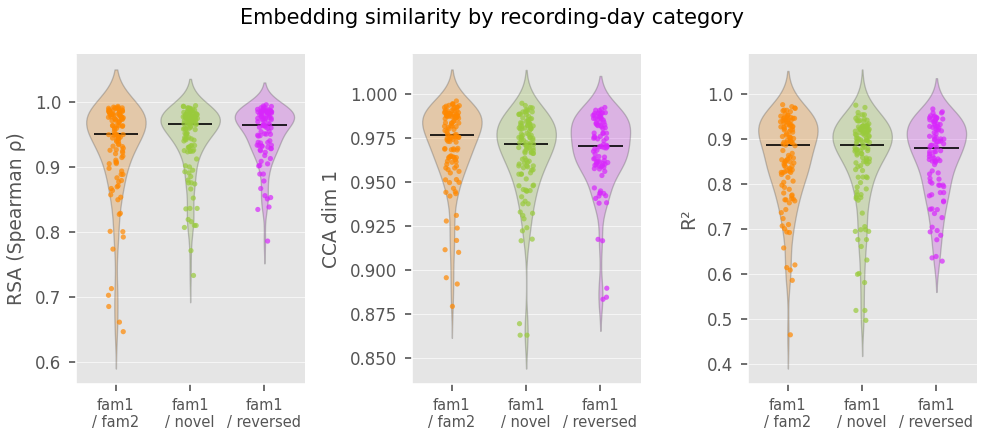

In [9]:
# Add experiment-type column
df["exp_type"] = df["session"].map(SESSION_TYPE_MAP)

exp_order_data = sorted(
    df["exp_type"].unique(),
    key=lambda x: EXPERIMENT_TYPE_ORDER.index(x) if x in EXPERIMENT_TYPE_ORDER else 99,
)
exp_palette = {et: EXPERIMENT_TYPE_COLORS.get(et, "#999999") for et in exp_order_data}

fig, axes = plt.subplots(1, 3, figsize=(PlotStyle.FULL_WIDTH, 3.0))

for ax, col, ylabel in zip(axes, metric_names, metric_labels):
    sns.violinplot(
        data=df, x="exp_type", y=col, hue="exp_type",
        order=exp_order_data, hue_order=exp_order_data,
        palette=exp_palette, inner=None, alpha=0.3, ax=ax, legend=False,
    )
    sns.stripplot(
        data=df, x="exp_type", y=col, hue="exp_type",
        order=exp_order_data, hue_order=exp_order_data,
        palette=exp_palette, size=2.5, alpha=0.7, jitter=True, ax=ax, legend=False,
    )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(range(len(exp_order_data)))
    ax.set_xticklabels(
        [e.replace(" / ", "\n/ ") for e in exp_order_data], fontsize=7,
    )

    for i, et in enumerate(exp_order_data):
        vals = df.loc[df["exp_type"] == et, col]
        if len(vals) > 0:
            ax.hlines(vals.median(), i - 0.3, i + 0.3, color="k", linewidth=0.8)

fig.suptitle("Embedding similarity by recording-day category", fontsize=10)
plt.tight_layout()
fig.savefig(fig_path / "metrics_by_experiment_type.pdf")
plt.show()

## 6 — Metric vs number of neurons

Does the agreement between embeddings depend on population size?

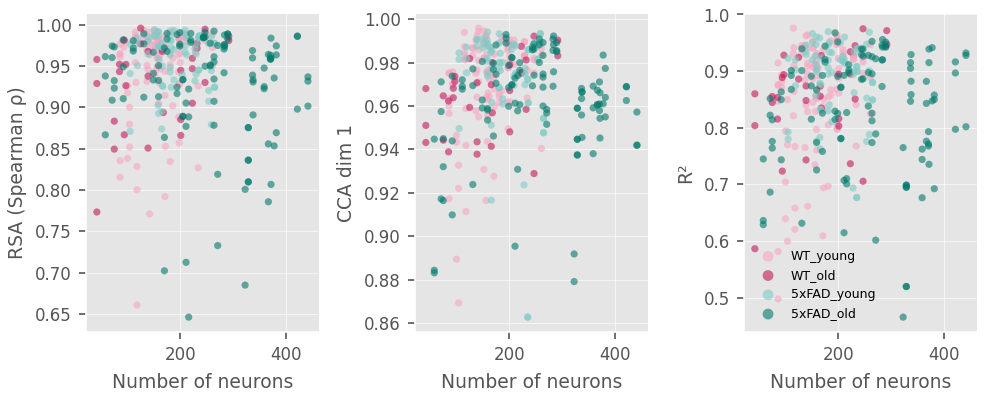

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(PlotStyle.FULL_WIDTH, 2.8))

for ax, col, ylabel in zip(axes, metric_names, metric_labels):
    for g in GROUP_ORDER:
        mask = df["group"] == g
        ax.scatter(df.loc[mask, "n_neurons"], df.loc[mask, col],
                   c=palette[g], s=12, alpha=0.6, label=g, edgecolors="none")
    ax.set_xlabel("Number of neurons")
    ax.set_ylabel(ylabel)

axes[-1].legend(fontsize=6, markerscale=1.5, frameon=False)
plt.tight_layout()
fig.savefig(fig_path / "metrics_vs_n_neurons.pdf")
plt.show()

## 7 — Gallery: ring comparison across all groups

A wider gallery showing more recordings (up to 4 per group), with PCA and PLSSVD side by side.

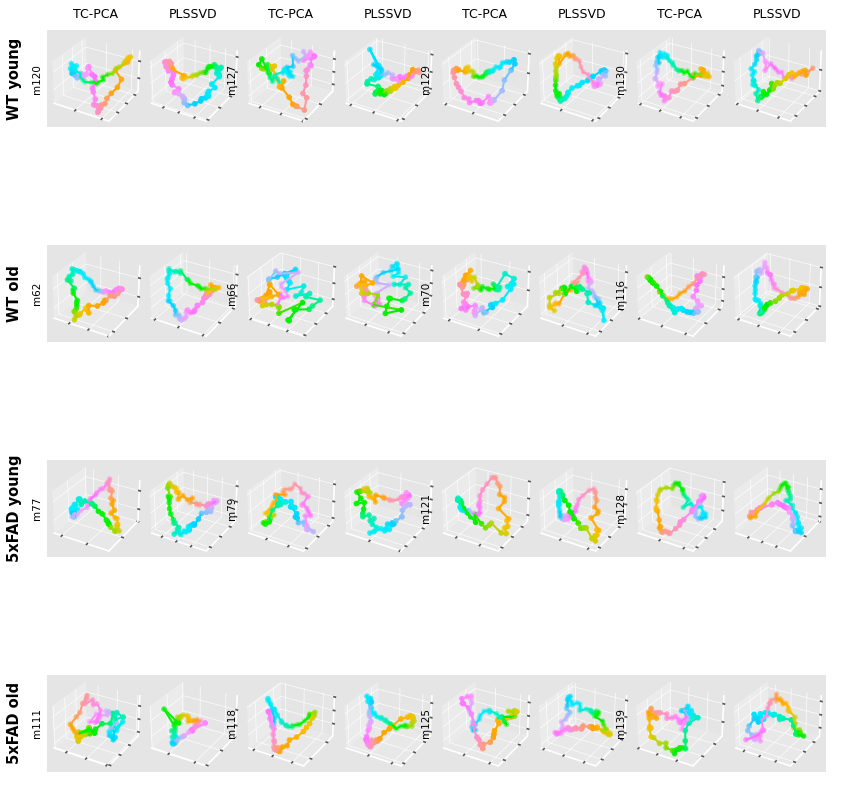

In [11]:
N_EXAMPLES = 4  # per group
norm = plt.Normalize(0, 360)

# Collect examples — pick distinct subjects where possible
gallery = {g: [] for g in GROUP_ORDER}
seen_subjects = {g: set() for g in GROUP_ORDER}
for rec in records:
    g = rec["group"]
    s = rec["subject"]
    if len(gallery[g]) < N_EXAMPLES and s not in seen_subjects[g]:
        gallery[g].append(rec)
        seen_subjects[g].add(s)
# Fill remaining slots if not enough distinct subjects
for rec in records:
    g = rec["group"]
    if len(gallery[g]) < N_EXAMPLES:
        gallery[g].append(rec)

nrows = len(GROUP_ORDER)
ncols = N_EXAMPLES * 2  # PCA + PLS side by side

fig, axes_flat = plt.subplots(
    nrows, ncols, figsize=(PlotStyle.FULL_WIDTH, 1.8 * nrows),
    subplot_kw={"projection": "3d"},
)
fig.subplots_adjust(wspace=0.0, hspace=0.15)

for row, group in enumerate(GROUP_ORDER):
    for ex_i, rec in enumerate(gallery[group]):
        for j, (ring, label) in enumerate([
            (rec["ring_pca"], "TC-PCA"),
            (rec["ring_pls"], "PLSSVD"),
        ]):
            ax = axes_flat[row, ex_i * 2 + j]
            phi_c = rec["ring_phi"]
            for k in range(len(ring)):
                k1 = (k + 1) % len(ring)
                ax.plot(
                    [ring[k, 0], ring[k1, 0]],
                    [ring[k, 1], ring[k1, 1]],
                    [ring[k, 2], ring[k1, 2]],
                    color=PHI_CMAP(norm(phi_c[k])), linewidth=1.0,
                )
            ax.scatter(ring[:, 0], ring[:, 1], ring[:, 2],
                       c=phi_c, cmap=PHI_CMAP, norm=norm, s=5, zorder=5)
            ax.tick_params(labelsize=5)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_zticklabels([])

            if row == 0:
                ax.set_title(label, fontsize=6)
            if j == 0:
                ax.text2D(-0.05, 0.5, rec["subject"].value, fontsize=5,
                          transform=ax.transAxes, va="center", ha="right", rotation=90)
 
    # Group label on far left
    axes_flat[row, 0].text2D(-0.25, 0.5, group.replace("_", " "), fontsize=7,
                             fontweight="bold", transform=axes_flat[row, 0].transAxes,
                             va="center", ha="right", rotation=90)

fig.savefig(fig_path / "ring_gallery_all_groups.pdf")
plt.show()

## 8 — Summary table

Group-level medians ± IQR for each metric.

In [12]:
def median_iqr(s):
    """Format as 'median [Q1, Q3]'."""
    med = s.median()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return f"{med:.3f} [{q1:.3f}, {q3:.3f}]"

summary_rows = []
for g in GROUP_ORDER:
    mask = df["group"] == g
    row = {"Group": g.replace("_", " ")}
    for col in metric_names:
        row[col] = median_iqr(df.loc[mask, col])
    row["n"] = int(mask.sum())
    summary_rows.append(row)

# Overall
row_all = {"Group": "All"}
for col in metric_names:
    row_all[col] = median_iqr(df[col])
row_all["n"] = len(df)
summary_rows.append(row_all)

df_summary = pd.DataFrame(summary_rows).set_index("Group")
df_summary

,RSA,CCA_dim1,R2,n
Group,,,,
WT young,"0.967 [0.931, 0.981]","0.978 [0.963, 0.987]","0.889 [0.829, 0.927]",105
WT old,"0.949 [0.902, 0.971]","0.968 [0.950, 0.976]","0.858 [0.816, 0.902]",32
5xFAD young,"0.972 [0.942, 0.984]","0.980 [0.970, 0.987]","0.906 [0.855, 0.933]",71
5xFAD old,"0.949 [0.905, 0.975]","0.967 [0.956, 0.977]","0.858 [0.771, 0.915]",113
All,"0.963 [0.925, 0.981]","0.974 [0.959, 0.984]","0.885 [0.812, 0.925]",321
